# Synthetic control example

Helpful code: https://github.com/sdfordham/pysyncon/blob/main/examples/germany.ipynb

Package documentation: https://github.com/sdfordham/pysyncon/blob/9aa6b546d7f96c1e699e9ed145214d6ff17fee12/pysyncon/synth.py

website for package: https://sdfordham.github.io/pysyncon/dataprep.html#pysyncon.Dataprep

Paper: https://www.mit.edu/~jhainm/Paper/ccs.pdf

R code: https://github.com/causalify-code/synthetic-control-replications/blob/main/california-tobacco-control-program/replication-abadie-diamond-hainmueller-california-proposition-99-tobacco-control-program-synthetic-control.R

Paper about the R package: https://www.jstatsoft.org/article/view/v042i13

In [37]:
import pandas as pd
import numpy as np

# import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

from pysyncon import Dataprep, Synth
from pysyncon.utils import PlaceboTest

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [38]:
# url = "https://raw.githubusercontent.com/matheusfacure/python-causality-handbook/refs/heads/master/causal-inference-for-the-brave-and-true/data/smoking.csv"
url = "https://raw.githubusercontent.com/causalify-code/synthetic-control-replications/refs/heads/main/california-tobacco-control-program/data-abadie-diamond-hainmueller-california-proposition-99-tobacco-control-program-synthetic-control.csv"

df = pd.read_csv(url)
# helpful filter for later
df['california'] = (df['state_name'] == 'California')
df['after_treatment'] = (df['year'] >= 1989)


In [39]:
# get the average cigarette sales by year for california and for the rest of the country
plot_df = df.groupby(['year', 'california'])['cigsale'].mean().reset_index()
# reset index so year and california are separate columns
plot_df = plot_df.reset_index()

# replace True and False value with "California" and "Rest of US", for plotting purpose
replace_dict = {True: 'California', False: 'Rest of US'}
plot_df['california'] = plot_df['california'].replace(replace_dict)

plot_df.head()

,index,year,california,cigsale
0,0,1970,Rest of US,120.084212
1,1,1970,California,123.000000
2,2,1971,Rest of US,123.863158
3,3,1971,California,121.000000
4,4,1972,Rest of US,129.178948


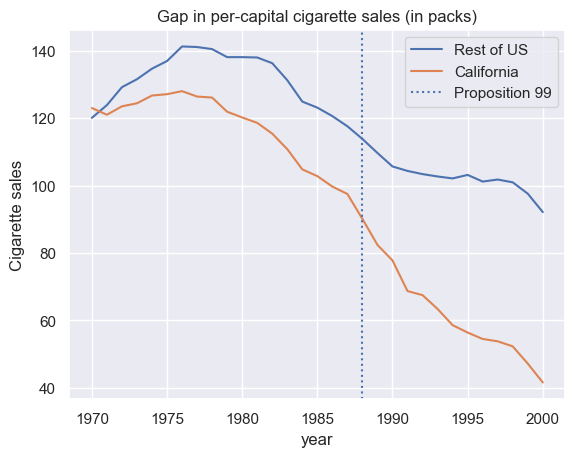

In [40]:
fig, ax = plt.subplots()

sns.lineplot(plot_df, x='year', y='cigsale', hue='california')

ax.set_title('Gap in per-capital cigarette sales (in packs)')
ax.set_ylabel('Cigarette sales')

ax.axvline(x=1988, linestyle=':', label='Proposition 99')

ax.legend()

## Using linear regression to estimate synthetic control

What if we try using linear regression to estimate synthetic control? 

In [5]:
X_row_filter = (
    (df['after_treatment'] == False)
    & (df['california'] == False)
)

X_df = (
    df.loc[X_row_filter, ['year', 'state', 'retprice', 'cigsale']]
    .pivot(index='state', columns='year')
    .T
    .values
)

y_row_filter = (
    (df['after_treatment'] == False)
    & (df['california'] == True)
)
y_df = (
    df.loc[y_row_filter, ['year', 'state', 'retprice', 'cigsale']]
    .pivot(index='state', columns='year')
    .T
    .values
)



In [6]:
ols_mod = LinearRegression(fit_intercept=False)
ols_res = ols_mod.fit(X=X_df, y=y_df)

linreg_weights = ols_res.coef_
print(linreg_weights)

[[-0.43564956 -1.0382365   0.67929274  0.07802904  0.33924148  1.21262963
   0.14334071  0.55490492 -0.29542045  0.05191322 -0.5292719   1.23494613
  -0.54869966  0.43692977 -0.02300476 -0.26620638 -0.24962542 -0.66656551
  -0.10564249 -0.14494033  0.10904801  0.24187147 -0.32757585  0.59443275
   0.2428527  -0.17098894 -0.02035279  0.13984751 -0.81132922  0.36150496
   0.51948684 -0.30366811  0.80489247 -0.31790943 -1.24612619  0.77300207
  -0.05529192 -0.03203286]]


In [7]:
filter_row = (df['california'] == False)
calif_linreg = (
    df.loc[filter_row, ['year', 'state', 'cigsale']]
    .pivot(index='year', columns='state')
    # .values
    @ (linreg_weights.T)
)
calif_linreg.rename(columns={0: 'cigsale'}, inplace=True)
calif_linreg.reset_index(inplace=True)
calif_linreg


,year,cigsale
0,1970,123.000000
1,1971,121.000000
2,1972,123.500000
3,1973,124.400001
4,1974,126.699997
5,1975,127.099998
6,1976,128.000000
7,1977,126.400001
8,1978,126.099998
9,1979,121.900001


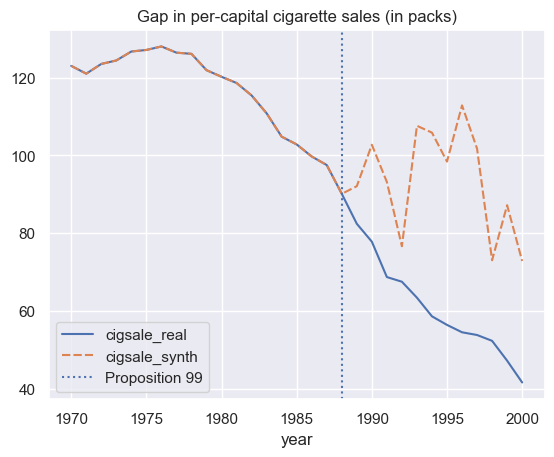

In [8]:
# # get the average cigarette sales by year for california and for the rest of the country
# plot_df = df.groupby(['year', 'california'])['cigsale'].mean().reset_index()
# # reset index so year and california are separate columns
# plot_df = plot_df.reset_index()

# # replace True and False value with "California" and "Rest of US", for plotting purpose
# replace_dict = {True: 'California', False: 'Rest of US'}
# plot_df['california'] = plot_df['california'].replace(replace_dict)

# plot_df.head()
plot_df = pd.merge(
    left=df.loc[df['california'] == True, ['year', 'cigsale']],
    right=calif_linreg,
    on='year',
    suffixes=['_real', '_synth']
)
plot_df.set_index('year', inplace=True)

fig, ax = plt.subplots()

sns.lineplot(plot_df)

ax.set_title('Gap in per-capital cigarette sales (in packs)')
# ax.set_ylabel('Cigarette sales')

ax.axvline(x=1988, linestyle=':', label='Proposition 99')

ax.legend()

## Estimating synthetic control

Suppose there are $J+1$ states, and $j=1$ is the treated state.

Our synthetic outcome will be a linear combination of the observed, non-treated $Y_{jt}$ from the donor pool.
\begin{equation*}
\hat{Y}_{t} = \sum_{j=2}^{J + 1} w_j Y_{jt}
\end{equation*}
We'll find weights $\mathbf{W} = (w_2, \dots, w_{J+1})$ that minimizes:
\begin{equation*}
\vert\vert X_w - X_0 \mathbf{W}\vert\vert = 
\sqrt{(X_1 - X_0 W)^\prime V (X_1 - X_0 W)}
\end{equation*}
Where $V$ is some $k \times k$ symmetric and positive definite matrix.
$V$ is often diagonal with elements $v_1, v_2, \dots, v_k$ on the diagonal
In that case, the synthetic control method minmizes:
\begin{equation*}
\sum_{m=1}^k v_m \left( X_{1m} - \sum_{j=1}^{J+1} w_j X_{jm} \right)^2
\end{equation*}

In [14]:
# donor pool
state_list = [state for state in df['state_name'].unique() if state != 'California']
T_0 = df.loc[df['after_treatment'] == True, 'year'].min()

dataprep = Dataprep(
    foo=df, 
    predictors=['retprice', 'lnincome', 'age15to24'],
    special_predictors = [
        ('beer', range(1984, T_0), 'mean'),
        ("cigsale", [1975], "mean"),
        ("cigsale", [1980], "mean"),
        ("cigsale", [1988], "mean")
    ],
    predictors_op='mean',
    dependent='cigsale',
    time_predictors_prior=range(1970, T_0),
    unit_variable='state_name',
    time_variable='year',
    treatment_identifier='California',
    controls_identifier=state_list,
    time_optimize_ssr=range(1970, T_0)
)

print(dataprep)

Dataprep
Treated unit: California
Dependent variable: cigsale
Control units: Alabama, Arkansas, Colorado, Connecticut, Delaware, Georgia, Idaho, Illinois, Indiana, Iowa, Kansas, Kentucky, Louisiana, Maine, Minnesota, Mississippi, Missouri, Montana, Nebraska, Nevada, New Hampshire, New Mexico, North Carolina, North Dakota, Ohio, Oklahoma, Pennsylvania, Rhode Island, South Carolina, South Dakota, Tennessee, Texas, Utah, Vermont, Virginia, West Virginia, Wisconsin, Wyoming
Time range in data: 1970 - 2000
Time range for loss minimization: range(1970, 1989)
Time range for predictors: range(1970, 1989)
Predictors: retprice, lnincome, age15to24
Special predictors:
    `beer` over `range(1984, 1989)` using `mean`
    `cigsale` over `[1975]` using `mean`
    `cigsale` over `[1980]` using `mean`
    `cigsale` over `[1988]` using `mean`



In [15]:
synth = Synth()
synth.fit(dataprep=dataprep, optim_method="Nelder-Mead", optim_initial="equal")

In [16]:
synth.weights().loc[synth.weights() != 0]

Colorado       0.091
Connecticut    0.160
Montana        0.248
Nevada         0.212
Utah           0.289
Name: weights, dtype: float64

In [17]:
synth.summary()

,V,treated,synthetic,sample mean
retprice,0.186,66.637,66.586,64.505
lnincome,0.003,10.032,9.852,9.792
age15to24,0.171,0.179,0.179,0.178
special.1.beer,0.128,24.280,24.211,23.655
special.2.cigsale,0.230,127.100,125.656,136.932
special.3.cigsale,0.160,120.200,120.365,138.089
special.4.cigsale,0.122,90.100,92.969,113.824


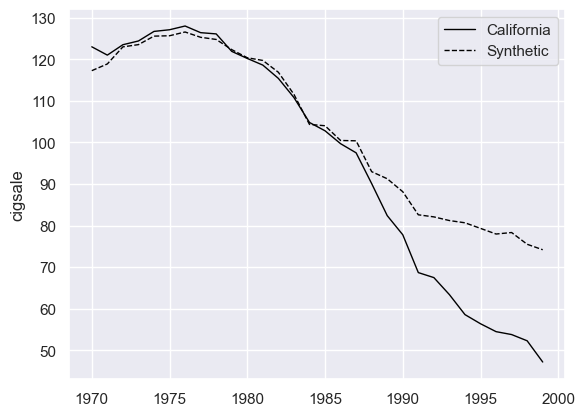

In [18]:
synth.path_plot(time_period=range(1970, 2000))

In [19]:
synth.att(time_period=range(1989, 2001))

{'att': -19.624221429780444, 'se': 1.8183430955806081}

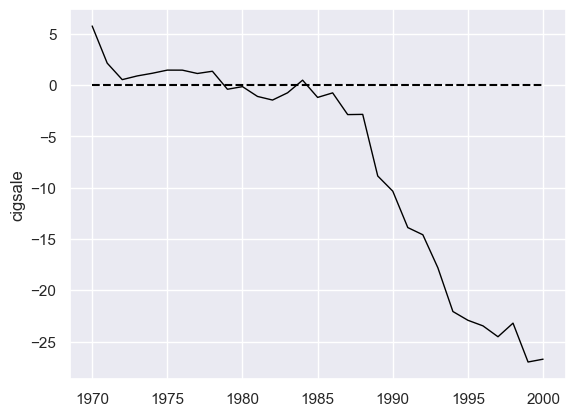

In [20]:
synth.gaps_plot(time_period=range(1970, 2001))

In [21]:
synth.mspe()

3.6889025738875727

In [22]:
synth.mape()

0.012943955472354737

In [23]:
synth.mae()

1.467946348702443

In [24]:
# synth.confidence_interval(alpha=0.05, time_periods=range(1989,2000), tol=0.01)

## Placebo test

In [25]:
placebo_test = PlaceboTest()

In [26]:
from concurrent import futures
import copy

placebo_test = PlaceboTest()

paths, gaps = list(), list()
n_tests = len(dataprep.controls_identifier)
with futures.ProcessPoolExecutor() as executor:
    to_do = list()
    for treated, controls in placebo_test.placebo_iter(dataprep.controls_identifier):
        _dataprep = copy.copy(dataprep)
        _dataprep.treatment_identifier = treated
        _dataprep.controls_identifier = controls
        to_do.append(
            executor.submit(
                placebo_test._single_placebo,
                dataprep=_dataprep,
                scm=synth,
                scm_options={"optim_method": "Nelder-Mead", "optim_initial": "equal"},
            )
        )
    for idx, future in enumerate(futures.as_completed(to_do), 1):
        path, gap = future.result()
        print(f"({idx}/{n_tests}) Completed placebo test for {path.name}.")
        paths.append(path)
        gaps.append(gap)

(1/38) Completed placebo test for Connecticut.
(2/38) Completed placebo test for Arkansas.
(3/38) Completed placebo test for Idaho.
(4/38) Completed placebo test for Georgia.
(5/38) Completed placebo test for Colorado.
(6/38) Completed placebo test for Kentucky.
(7/38) Completed placebo test for Minnesota.
(8/38) Completed placebo test for Iowa.
(9/38) Completed placebo test for Nevada.
(10/38) Completed placebo test for Indiana.
(11/38) Completed placebo test for New Hampshire.
(12/38) Completed placebo test for Mississippi.
(13/38) Completed placebo test for Maine.
(14/38) Completed placebo test for Illinois.
(15/38) Completed placebo test for New Mexico.
(16/38) Completed placebo test for Ohio.
(17/38) Completed placebo test for Nebraska.
(18/38) Completed placebo test for North Carolina.
(19/38) Completed placebo test for Delaware.
(20/38) Completed placebo test for Pennsylvania.
(21/38) Completed placebo test for North Dakota.
(22/38) Completed placebo test for Utah.
(23/38) Compl

In [27]:
path_df = pd.concat(paths, axis=1)
gap_df = pd.concat(gaps, axis=1)
time_optimize_ssr = dataprep.time_optimize_ssr

placebo_test.paths = path_df
placebo_test.gaps = gap_df 
placebo_test.time_optimize_ssr = dataprep.time_optimize_ssr

In [28]:
print(f"Calculating treated unit gaps.")
treated_path, treated_gap = placebo_test._single_placebo(
    dataprep=dataprep, scm=synth, scm_options={"optim_method": "Nelder-Mead", "optim_initial": "equal"}
)

placebo_test.treated_path = treated_path
placebo_test.treated_gap = treated_gap

print("Done.")

Calculating treated unit gaps.
Done.


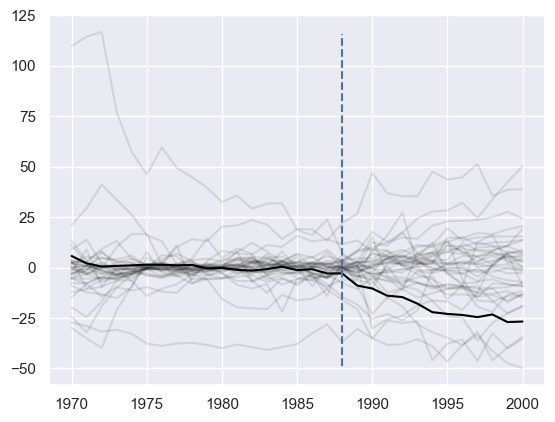

In [29]:
placebo_test.gaps_plot(
    time_period=range(1970, 2001),
    treatment_time=1988
)

(-35.0, 35.0)

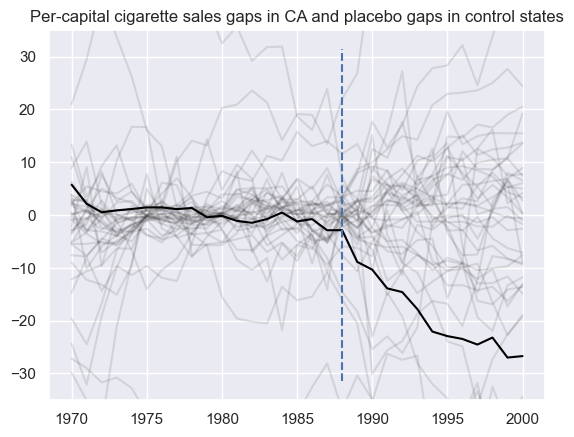

In [30]:
time_period = range(1970, 2001)
exclude_units = None
treatment_time = 1988
mspe_threshold = None
exclude_units = None

fig, ax = plt.subplots()

gaps = placebo_test.gaps.drop(columns=exclude_units) if exclude_units else placebo_test.gaps

if mspe_threshold:
    if not treatment_time:
        raise ValueError("Need `treatment_time` to use `mspe_threshold`.")
    pre_mspe = gaps.loc[:treatment_time].pow(2).sum(axis=0)
    pre_mspe_treated = placebo_test.treated_gap.loc[:treatment_time].pow(2).sum(axis=0)
    keep = pre_mspe[pre_mspe < mspe_threshold * pre_mspe_treated].index
    placebo_gaps = gaps[gaps.index.isin(time_period)][keep]
else:
    placebo_gaps = gaps[gaps.index.isin(time_period)]

ax.plot(placebo_gaps, color="black", alpha=0.1)
ax.plot(placebo_test.treated_gap, color="black", alpha=1.0)
if treatment_time:
    ax.axvline(x=treatment_time, ymin=0.05, ymax=0.95, linestyle="dashed")

ax.set_title('Per-capital cigarette sales gaps in CA and placebo gaps in control states')
ax.set_ylim(-35, 35)

(-35.0, 35.0)

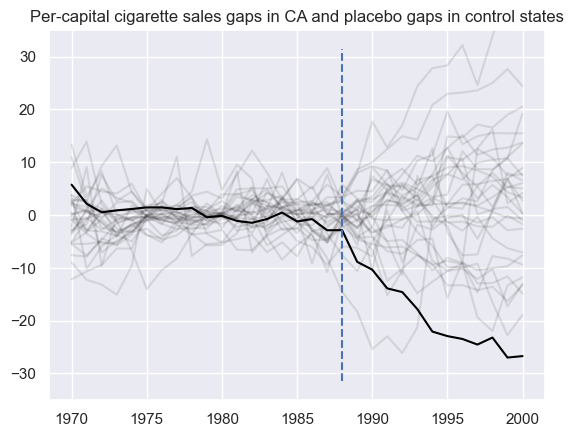

In [31]:
time_period = range(1970, 2001)
exclude_units = None
treatment_time = 1988
mspe_threshold = 20
exclude_units = None

fig, ax = plt.subplots()

gaps = placebo_test.gaps.drop(columns=exclude_units) if exclude_units else placebo_test.gaps

if mspe_threshold:
    if not treatment_time:
        raise ValueError("Need `treatment_time` to use `mspe_threshold`.")
    pre_mspe = gaps.loc[:treatment_time].pow(2).sum(axis=0)
    pre_mspe_treated = placebo_test.treated_gap.loc[:treatment_time].pow(2).sum(axis=0)
    keep = pre_mspe[pre_mspe < mspe_threshold * pre_mspe_treated].index
    placebo_gaps = gaps[gaps.index.isin(time_period)][keep]
else:
    placebo_gaps = gaps[gaps.index.isin(time_period)]

ax.plot(placebo_gaps, color="black", alpha=0.1)
ax.plot(placebo_test.treated_gap, color="black", alpha=1.0)
if treatment_time:
    ax.axvline(x=treatment_time, ymin=0.05, ymax=0.95, linestyle="dashed")

ax.set_title('Per-capital cigarette sales gaps in CA and placebo gaps in control states')
ax.set_ylim(-35, 35)

In [32]:
treatment_time = 1988

all_ = pd.concat([placebo_test.gaps, placebo_test.treated_gap], axis=1)

denom = all_.loc[:treatment_time].pow(2).sum(axis=0)
num = all_.loc[treatment_time:].pow(2).sum(axis=0)

t, _ = placebo_test.gaps.shape
t0, _ = placebo_test.gaps.loc[:treatment_time].shape

rmspe = (num / (t - t0)) / (denom / t0)

sum(
    rmspe.drop(index=placebo_test.treated_gap.name) >= rmspe.loc[placebo_test.treated_gap.name]
) / len(rmspe)


rmspe

sum((rmspe.drop(index='California') / rmspe.loc['California']) / len(rmspe))

0.09264668371453273

In [33]:
T = len(placebo_test.gaps)               # n years in data
T_0 = len(placebo_test.gaps.loc[:1988])  # n years in pre-treatment

# create a dataframe with all of the gaps
gaps_all = pd.concat([placebo_test.gaps, placebo_test.treated_gap], axis=1)
(gaps_all**2).sum()
# placebo_test.treated_gap
# ((placebo_test.treated_gap / placebo_test.treated_path)**2).sum()

# (1 / t0) * (placebo_test.treated_gap**2).sum()

# placebo_test.treated_gap

squared_gap_pre = gaps_all[gaps_all.index <= 1988]**2

mspe_pre = (gaps_all[gaps_all.index <= 1988]**2).mean()
rmspe_pre = np.sqrt(mspe_pre)

rmspe_post = np.sqrt((gaps_all[gaps_all.index > 1988]**2).mean())

rmspe_ratio = rmspe_post / rmspe_pre
# sort values from highest to lowest
rmspe_ratio.sort_values(ascending=False, inplace=True)
rmspe_ratio

California        10.689071
Missouri           7.451750
Georgia            7.316744
Virginia           7.193032
Indiana            5.246253
Tennessee          4.815126
Illinois           4.787326
South Carolina     4.215589
Texas              4.175539
Delaware           4.051943
New Mexico         3.955019
Wisconsin          3.507587
Louisiana          3.366044
Maine              2.983984
Montana            2.844680
Rhode Island       2.738952
Oklahoma           2.706314
West Virginia      2.638196
Idaho              2.276895
Nevada             2.228243
Mississippi        2.197882
South Dakota       1.971588
Kentucky           1.962914
Minnesota          1.769410
North Carolina     1.720793
Ohio               1.658631
Alabama            1.600547
Connecticut        1.551792
Vermont            1.408792
Iowa               1.281085
Pennsylvania       1.158728
Nebraska           1.145906
Utah               1.063680
Arkansas           1.020161
Colorado           0.778572
Wyoming            0

<Axes: xlabel='Ratio', ylabel='Count'>

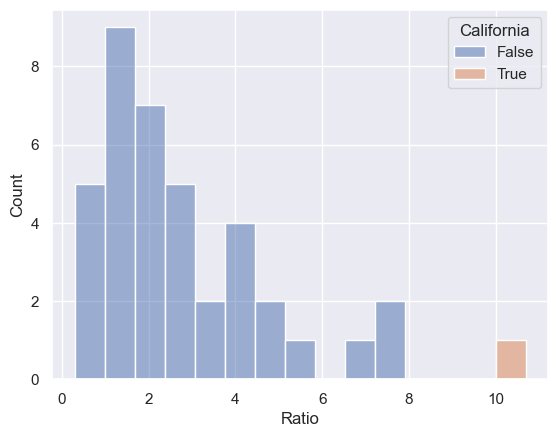

In [34]:
fig, ax = plt.subplots()

# sns.histplot(rmspe_ratio, bins=15, freq=True)
plot_df = rmspe_ratio.to_frame(name='Ratio')
plot_df['California'] = (plot_df.index == 'California')

sns.histplot(data=plot_df, x='Ratio', hue='California', bins=15)

In [35]:
print(f'Preintervention MSPE in California: {synth.mspe():.2f}')
print(f'Median Preintervention MSPE in donor pool: {rmspe_pre.median()**2:.2f}')
max_mspe = mspe_pre.drop('California').sort_values(ascending=False).index[0]
print(f'State with largest preintervention MSPE: {max_mspe}')
print(f'{max_mspe}\' MSPE: {mspe_pre.loc[max_mspe]:,.0f}')



Preintervention MSPE in California: 3.69
Median Preintervention MSPE in donor pool: 14.15
State with largest preintervention MSPE: New Hampshire
New Hampshire' MSPE: 3,485


(-35.0, 35.0)

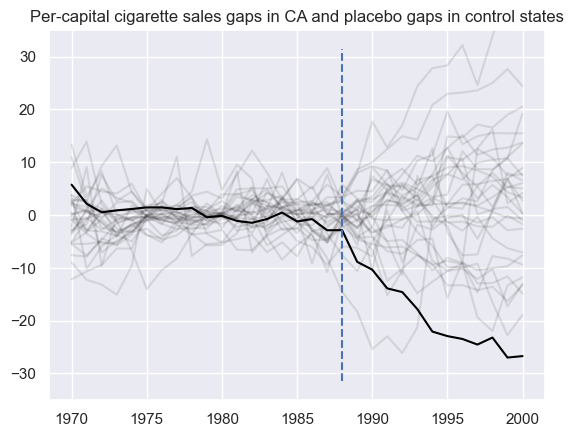

In [36]:
mspe_pre.loc[mspe_pre < (mspe_pre.loc['California']*20)]

time_period = range(1970, 2001)
exclude_units = None
treatment_time = 1988
mspe_threshold = 20
exclude_units = None

fig, ax = plt.subplots()

gaps = placebo_test.gaps.drop(columns=exclude_units) if exclude_units else placebo_test.gaps

if mspe_threshold:
    if not treatment_time:
        raise ValueError("Need `treatment_time` to use `mspe_threshold`.")
    pre_mspe = gaps.loc[:treatment_time].pow(2).sum(axis=0)
    pre_mspe_treated = placebo_test.treated_gap.loc[:treatment_time].pow(2).sum(axis=0)
    keep = pre_mspe[pre_mspe < mspe_threshold * pre_mspe_treated].index
    placebo_gaps = gaps[gaps.index.isin(time_period)][keep]
else:
    placebo_gaps = gaps[gaps.index.isin(time_period)]

ax.plot(placebo_gaps, color="black", alpha=0.1)
ax.plot(placebo_test.treated_gap, color="black", alpha=1.0)
if treatment_time:
    ax.axvline(x=treatment_time, ymin=0.05, ymax=0.95, linestyle="dashed")

ax.set_title('Per-capital cigarette sales gaps in CA and placebo gaps in control states')
ax.set_ylim(-35, 35)

In [275]:
# check i understand mspe
abs(
    ((placebo_test.treated_gap.loc[placebo_test.treated_gap.index <= 1988])**2).mean().item()
    - 
    synth.mspe()
) < 1e-8

True

In [ ]:
denom = all_.loc[:treatment_time].pow(2).sum(axis=0)


Connecticut         483.514458
Arkansas           2284.781681
Idaho               145.993801
Georgia              35.358960
Colorado            428.049185
Kentucky           8167.922871
Minnesota           326.573472
Iowa                272.561739
Indiana             276.040480
Nevada             1546.590688
New Hampshire     66223.688974
Mississippi         109.213532
Maine               268.841983
Illinois             71.086715
New Mexico           87.613586
Ohio                 76.553930
Nebraska            121.782175
Delaware            974.318683
North Carolina     7835.281451
Pennsylvania        166.926899
North Dakota        656.717817
Utah              24272.249532
Oklahoma            656.814949
Texas               145.325501
Tennessee           135.222578
Louisiana           128.019026
Kansas              349.888603
Alabama             213.556820
South Dakota        167.738426
South Carolina       58.438032
Virginia             65.690949
Wyoming            1392.305288
Vermont 